In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [ ]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/26 12:23:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

all_evidence = session.spark.read.parquet(path_to_release_folder + "output/evidence")


efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


g_p_s = session.spark.read.parquet(path_to_intermediate_data_folder + "genes_therapeutic_areas")
g_p_s.count()


26/01/26 12:23:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

# TAs


In [ ]:
disease_index_orig.show(1)


+------------+--------------------+---------------+--------------------+--------------------+--------------------+--------------------+-------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|          id|                code|           name|         description|             dbXRefs|             parents|            synonyms|obsoleteTerms|obsoleteXRefs|            children|           ancestors|    therapeuticAreas|         descendants|            ontology|
+------------+--------------------+---------------+--------------------+--------------------+--------------------+--------------------+-------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|DOID_0050890|http://purl.oboli...|synucleinopathy|A neurodegenerati...|[MESH:D000080874,...|[MONDO_0019052, M...|{[alpha Synuclein...|           []|           []|[EFO_0006792, EFO...|[MONDO_00

In [ ]:
unique_tas = (
    disease_index_orig.select(f.explode(f.col("therapeuticAreas")).alias("ta"))
    .distinct()
    .rdd.map(lambda x: x[0])
    .collect()
)
for ta in sorted(unique_tas):
    print(ta)


EFO_0000319
EFO_0000540
EFO_0000618
EFO_0000651
EFO_0001379
EFO_0001444
EFO_0002571
EFO_0005741
EFO_0005803
EFO_0005932
EFO_0009605
EFO_0009690
EFO_0010282
EFO_0010285
GO_0008150
MONDO_0002025
MONDO_0021205
MONDO_0024458
MONDO_0045024
OTAR_0000006
OTAR_0000009
OTAR_0000010
OTAR_0000014
OTAR_0000017
OTAR_0000018
OTAR_0000020


In [ ]:
disease_index_orig.filter(f.col("id").isin(unique_tas)).select("id", "name").show(truncate=False, n=100)


+-------------+--------------------------------------------+
|id           |name                                        |
+-------------+--------------------------------------------+
|GO_0008150   |biological_process                          |
|MONDO_0002025|psychiatric disorder                        |
|MONDO_0021205|disorder of ear                             |
|MONDO_0024458|disorder of visual system                   |
|MONDO_0045024|cancer or benign tumor                      |
|EFO_0000319  |cardiovascular disease                      |
|EFO_0000540  |immune system disease                       |
|EFO_0000618  |nervous system disease                      |
|EFO_0000651  |phenotype                                   |
|EFO_0001379  |endocrine system disease                    |
|EFO_0001444  |measurement                                 |
|EFO_0002571  |medical procedure                           |
|EFO_0005741  |infectious disease                          |
|EFO_0005803  |hematolog

In [ ]:
ta_to_exclude = ["EFO_0001444", "MONDO_0045024", "GO_0008150", "EFO_0000651"]


In [ ]:
ta_to_anlyze = [ta for ta in unique_tas if ta not in ta_to_exclude]


In [ ]:
len(ta_to_anlyze)


22

In [ ]:
chembl_evidence.show(1)


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

In [ ]:
import pandas as pd

all_enrich = []

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)


for ta in ta_to_anlyze:
    print(ta)
    efo_to_include = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
        disease_index_orig=disease_index_orig,
        efo_ids=ta,
    )
    chembl_evidence_filtered = chembl_evidence.filter(f.col("diseaseId").isin(efo_to_include))

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence_filtered,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = ta
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


EFO_0005932


26/01/26 13:30:39 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:30:40 WARN CacheManager: Asked to cache already cached data.        


EFO_0005803


26/01/26 13:30:48 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:30:48 WARN CacheManager: Asked to cache already cached data.


EFO_0010285


26/01/26 13:31:03 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:31:03 WARN CacheManager: Asked to cache already cached data.


OTAR_0000020


26/01/26 13:31:16 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:31:17 WARN CacheManager: Asked to cache already cached data.


MONDO_0002025


26/01/26 13:31:30 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:31:30 WARN CacheManager: Asked to cache already cached data.


EFO_0005741


26/01/26 13:31:42 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:31:43 WARN CacheManager: Asked to cache already cached data.


EFO_0001379


26/01/26 13:31:56 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:31:56 WARN CacheManager: Asked to cache already cached data.


OTAR_0000014


26/01/26 13:32:09 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:32:10 WARN CacheManager: Asked to cache already cached data.


OTAR_0000009


26/01/26 13:32:22 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:32:22 WARN CacheManager: Asked to cache already cached data.


OTAR_0000010


26/01/26 13:32:34 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:32:35 WARN CacheManager: Asked to cache already cached data.


MONDO_0021205


26/01/26 13:32:46 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:32:47 WARN CacheManager: Asked to cache already cached data.


EFO_0009690


26/01/26 13:32:59 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:33:00 WARN CacheManager: Asked to cache already cached data.


EFO_0010282


26/01/26 13:33:12 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:33:13 WARN CacheManager: Asked to cache already cached data.


EFO_0002571


26/01/26 13:33:24 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:33:25 WARN CacheManager: Asked to cache already cached data.


EFO_0000618


26/01/26 13:33:39 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:33:40 WARN CacheManager: Asked to cache already cached data.        
26/01/26 13:33:41 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB
26/01/26 13:33:42 WARN DAGScheduler: Broadcasting large task binary with size 1021.9 KiB
26/01/26 13:33:43 WARN DAGScheduler: Broadcasting large task binary with size 1022.5 KiB
26/01/26 13:33:45 WARN DAGScheduler: Broadcasting large task binary with size 1022.7 KiB
26/01/26 13:33:46 WARN DAGScheduler: Broadcasting large task binary with size 1021.8 KiB
26/01/26 13:33:47 WARN DAGScheduler: Broadcasting large task binary with size 1021.9 KiB
26/01/26 13:33:49 WARN DAGScheduler: Broadcasting large task binary with size 1022.5 KiB
26/01/26 13:33:50 WARN DAGScheduler: Broadcasting large task binary with size 1022.7 KiB
26/01/26 13:33:51 WARN DAGScheduler: Broadcasting large task binary with size 1021.8 KiB
26/01/26 13:33:53 WARN DAGScheduler: Broadcas

MONDO_0024458


26/01/26 13:34:05 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:34:06 WARN CacheManager: Asked to cache already cached data.        


OTAR_0000006


26/01/26 13:34:27 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:34:28 WARN CacheManager: Asked to cache already cached data.        


OTAR_0000018


26/01/26 13:34:56 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:34:56 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:34:57 WARN DAGScheduler: Broadcasting large task binary with size 1476.7 KiB
26/01/26 13:34:58 WARN DAGScheduler: Broadcasting large task binary with size 1476.8 KiB
26/01/26 13:34:59 WARN DAGScheduler: Broadcasting large task binary with size 1477.5 KiB
26/01/26 13:35:00 WARN DAGScheduler: Broadcasting large task binary with size 1477.6 KiB
26/01/26 13:35:02 WARN DAGScheduler: Broadcasting large task binary with size 1476.7 KiB
26/01/26 13:35:04 WARN DAGScheduler: Broadcasting large task binary with size 1476.8 KiB
26/01/26 13:35:07 WARN DAGScheduler: Broadcasting large task binary with size 1477.5 KiB
26/01/26 13:35:10 WARN DAGScheduler: Broadcasting large task binary with size 1477.6 KiB
26/01/26 13:35:13 WARN DAGScheduler: Broadcasting large task binary with size 1476.7 KiB
26/01/26 13:35:16 WARN DAGScheduler: Broadcasting lar

EFO_0000319


26/01/26 13:35:29 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:35:30 WARN CacheManager: Asked to cache already cached data.        


EFO_0009605


26/01/26 13:35:55 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:35:56 WARN CacheManager: Asked to cache already cached data.        


EFO_0000540


26/01/26 13:36:19 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:36:20 WARN CacheManager: Asked to cache already cached data.        


OTAR_0000017


26/01/26 13:36:47 WARN CacheManager: Asked to cache already cached data.
26/01/26 13:36:48 WARN CacheManager: Asked to cache already cached data.        


In [ ]:
df_concat = pd.concat(all_enrich, ignore_index=True)


In [ ]:
combined_enrich_4 = df_concat[df_concat["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "Pharmaprojects"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "no_train_chembl"]
combined_enrich_4 = combined_enrich_4.iloc[::-1]


In [ ]:
names_ta = disease_index_orig.filter(f.col("id").isin(unique_tas)).select("id", "name").toPandas()


In [ ]:
names_ta


,id,name
0,GO_0008150,biological_process
1,MONDO_0002025,psychiatric disorder
2,MONDO_0021205,disorder of ear
3,MONDO_0024458,disorder of visual system
4,MONDO_0045024,cancer or benign tumor
5,EFO_0000319,cardiovascular disease
6,EFO_0000540,immune system disease
7,EFO_0000618,nervous system disease
8,EFO_0000651,phenotype
9,EFO_0001379,endocrine system disease


In [ ]:
combined_enrich_4 = combined_enrich_4.merge(
    names_ta[["id", "name"]], left_on="datasource", right_on="id", how="left"
).drop(columns=["id"])


In [ ]:
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource,name
0,4+,1.882353,3.187026e-01,0.419025,8.455949,1.764706,0.479185,6.498925,3.931350e-01,1248,102,13,2,151704,OTAR_0000017,full_chembl,reproductive system or breast disease
1,4+,3.732684,9.211482e-10,2.534223,5.497909,2.878720,2.192371,3.779940,2.762818e-14,3449,420,88,40,151704,EFO_0000540,full_chembl,immune system disease
2,4+,4.121483,1.121313e-05,2.231470,7.612304,2.595425,1.856743,3.627982,2.386181e-08,586,136,23,22,151704,EFO_0009605,full_chembl,pancreas disease
3,4+,5.066333,2.065954e-22,3.735572,6.871165,3.333142,2.774940,4.003631,6.284726e-38,4283,628,105,78,151704,EFO_0000319,full_chembl,cardiovascular disease
4,4+,3.786778,8.429849e-06,2.241622,6.397013,3.116540,2.086571,4.654922,2.803863e-08,5728,479,60,19,151704,OTAR_0000018,full_chembl,"genetic, familial or congenital disease"
5,4+,2.059306,2.272260e-02,1.149671,3.688658,1.825636,1.156714,2.881390,9.729962e-03,2845,391,53,15,151704,OTAR_0000006,full_chembl,musculoskeletal or connective tissue disease
6,4+,16.499163,1.708540e-12,7.716809,35.276548,6.683027,4.906631,9.102548,1.946445e-33,1557,163,11,19,151704,MONDO_0024458,full_chembl,disorder of visual system
7,4+,2.220918,3.424647e-04,1.474073,3.346156,1.953564,1.416789,2.693704,4.397697e-05,8452,1067,107,30,151704,EFO_0000618,full_chembl,nervous system disease
8,4+,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0,14,0,0,151704,EFO_0002571,full_chembl,medical procedure
9,4+,3.988074,4.302136e-04,2.006793,7.925447,3.330698,1.937974,5.724300,1.332510e-05,2432,172,39,11,151704,EFO_0010282,full_chembl,gastrointestinal disease


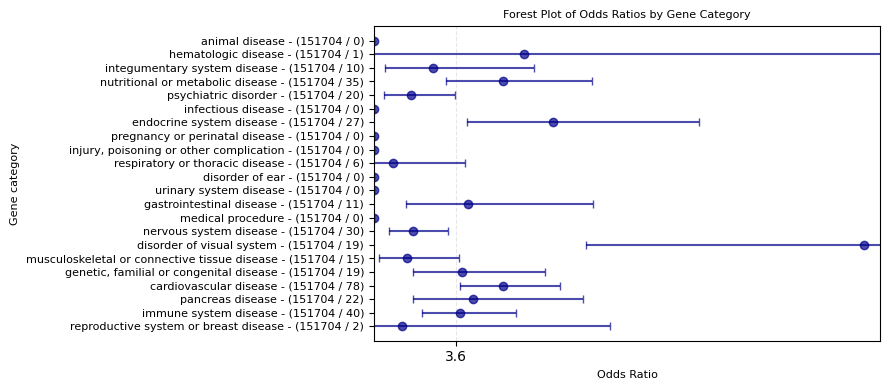

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasources and drugsources
# combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["name"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(9, 4))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["name"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Gene category", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Gene Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(1, 17)
plt.xticks([3.6])

# Adjust layout and show
plt.tight_layout()
plt.show()


## Leave-one-out


In [34]:
import pandas as pd

all_enrich = []

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)


for ta in ta_to_anlyze:
    print(ta)

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024", ta],
    )
    enrich["datasource"] = ta
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


EFO_0005932


EFO_0005803


EFO_0010285


OTAR_0000020


26/01/26 13:50:11 WARN DAGScheduler: Broadcasting large task binary with size 1110.8 KiB
26/01/26 13:50:13 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/01/26 13:50:15 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/01/26 13:50:17 WARN DAGScheduler: Broadcasting large task binary with size 1116.3 KiB
26/01/26 13:50:19 WARN DAGScheduler: Broadcasting large task binary with size 1116.5 KiB
26/01/26 13:50:21 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/01/26 13:50:23 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/01/26 13:50:25 WARN DAGScheduler: Broadcasting large task binary with size 1116.3 KiB
26/01/26 13:50:27 WARN DAGScheduler: Broadcasting large task binary with size 1116.5 KiB
26/01/26 13:50:29 WARN DAGScheduler: Broadcasting large task binary with size 1115.6 KiB
26/01/26 13:50:31 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/01/26 13:50:33 WAR

MONDO_0002025


EFO_0005741


EFO_0001379


OTAR_0000014


OTAR_0000009


OTAR_0000010


MONDO_0021205


EFO_0009690


EFO_0010282


EFO_0002571


EFO_0000618


26/01/26 13:55:02 WARN DAGScheduler: Broadcasting large task binary with size 1041.6 KiB
26/01/26 13:55:02 WARN DAGScheduler: Broadcasting large task binary with size 1369.3 KiB
26/01/26 13:55:04 WARN DAGScheduler: Broadcasting large task binary with size 1374.1 KiB
26/01/26 13:55:05 WARN DAGScheduler: Broadcasting large task binary with size 1374.3 KiB
26/01/26 13:55:07 WARN DAGScheduler: Broadcasting large task binary with size 1374.9 KiB
26/01/26 13:55:08 WARN DAGScheduler: Broadcasting large task binary with size 1375.0 KiB
26/01/26 13:55:10 WARN DAGScheduler: Broadcasting large task binary with size 1374.1 KiB
26/01/26 13:55:11 WARN DAGScheduler: Broadcasting large task binary with size 1374.3 KiB
26/01/26 13:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1374.9 KiB
26/01/26 13:55:14 WARN DAGScheduler: Broadcasting large task binary with size 1375.0 KiB
26/01/26 13:55:15 WARN DAGScheduler: Broadcasting large task binary with size 1374.1 KiB
26/01/26 13:55:17 WAR

MONDO_0024458


OTAR_0000006


26/01/26 13:55:54 WARN DAGScheduler: Broadcasting large task binary with size 1175.5 KiB
26/01/26 13:55:55 WARN DAGScheduler: Broadcasting large task binary with size 1180.3 KiB
26/01/26 13:55:56 WARN DAGScheduler: Broadcasting large task binary with size 1180.4 KiB
26/01/26 13:55:57 WARN DAGScheduler: Broadcasting large task binary with size 1181.1 KiB
26/01/26 13:55:57 WARN DAGScheduler: Broadcasting large task binary with size 1181.2 KiB
26/01/26 13:55:58 WARN DAGScheduler: Broadcasting large task binary with size 1180.3 KiB
26/01/26 13:55:59 WARN DAGScheduler: Broadcasting large task binary with size 1180.4 KiB
26/01/26 13:56:00 WARN DAGScheduler: Broadcasting large task binary with size 1181.1 KiB
26/01/26 13:56:01 WARN DAGScheduler: Broadcasting large task binary with size 1181.2 KiB
26/01/26 13:56:02 WARN DAGScheduler: Broadcasting large task binary with size 1180.3 KiB
26/01/26 13:56:03 WARN DAGScheduler: Broadcasting large task binary with size 1180.4 KiB
26/01/26 13:56:04 WAR

OTAR_0000018


26/01/26 13:56:22 WARN DAGScheduler: Broadcasting large task binary with size 1602.9 KiB
26/01/26 13:56:24 WARN DAGScheduler: Broadcasting large task binary with size 1601.5 KiB
26/01/26 13:56:25 WARN DAGScheduler: Broadcasting large task binary with size 1608.6 KiB
26/01/26 13:56:26 WARN DAGScheduler: Broadcasting large task binary with size 1951.6 KiB
26/01/26 13:56:27 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:28 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:31 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:33 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:36 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:39 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:43 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/01/26 13:56:45 WARN DAGScheduler: Broad

EFO_0000319


EFO_0009605


EFO_0000540


OTAR_0000017


In [ ]:
df_concat = pd.concat(all_enrich, ignore_index=True)

combined_enrich_4 = df_concat[df_concat["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "Pharmaprojects"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "no_train_chembl"]
combined_enrich_4 = combined_enrich_4.iloc[::-1]

names_ta = disease_index_orig.filter(f.col("id").isin(unique_tas)).select("id", "name").toPandas()

combined_enrich_4 = combined_enrich_4.merge(
    names_ta[["id", "name"]], left_on="datasource", right_on="id", how="left"
).drop(columns=["id"])
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource,name
0,4+,3.627782,8.848836e-49,3.097925,4.248264,2.760289,2.479323,3.073094,1.017727e-76,31065,4220,487,240,149604,OTAR_0000017,full_chembl,reproductive system or breast disease
1,4+,3.774778,5.363169e-43,3.173313,4.490245,2.837353,2.525184,3.188113,7.523947e-69,28884,3904,392,200,124868,EFO_0000540,full_chembl,immune system disease
2,4+,3.501329,3.806902e-43,2.973643,4.122655,2.710866,2.420787,3.035704,7.786395e-67,31730,4187,474,219,138740,EFO_0009605,full_chembl,pancreas disease
3,4+,3.158561,6.833193e-29,2.624196,3.801739,2.524146,2.211722,2.880702,6.300860e-43,28031,3694,394,164,132720,EFO_0000319,full_chembl,cardiovascular disease
4,4+,3.398750,7.837924e-39,2.868989,4.026333,2.606782,2.323435,2.924684,7.146778e-60,26603,3858,422,208,127665,OTAR_0000018,full_chembl,"genetic, familial or congenital disease"
5,4+,3.850062,3.465384e-49,3.267156,4.536968,2.882847,2.582068,3.218662,4.021071e-79,29477,3933,438,225,126128,OTAR_0000006,full_chembl,musculoskeletal or connective tissue disease
6,4+,3.356454,3.710710e-41,2.854776,3.946293,2.620683,2.341226,2.933497,6.010096e-63,30756,4160,489,222,144909,MONDO_0024458,full_chembl,disorder of visual system
7,4+,3.906116,1.370775e-45,3.285478,4.643995,2.894866,2.580714,3.247261,1.650154e-73,23868,3261,386,206,121413,EFO_0000618,full_chembl,nervous system disease
8,4+,3.630337,2.177735e-49,3.103663,4.246385,2.772464,2.490725,3.086073,1.241300e-77,32313,4308,500,242,150614,EFO_0002571,full_chembl,medical procedure
9,4+,3.590787,6.294997e-46,3.054179,4.221675,2.728447,2.445302,3.044376,4.314172e-72,29883,4152,459,229,139352,EFO_0010282,full_chembl,gastrointestinal disease


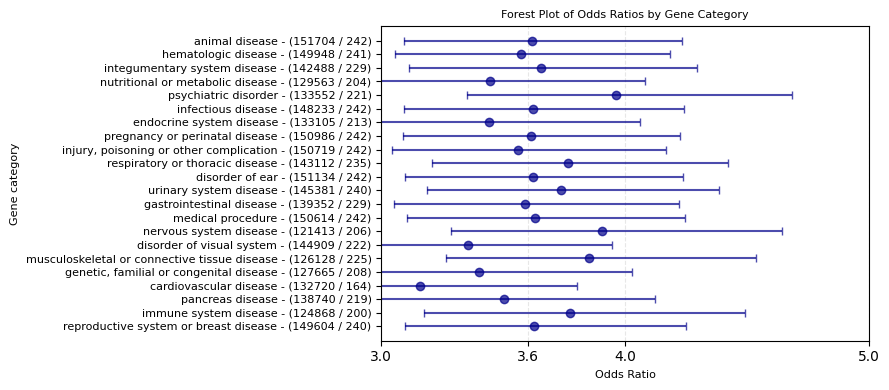

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasources and drugsources
# combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["name"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(9, 4))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["name"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Gene category", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Gene Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(3, 5)
plt.xticks([3, 3.6, 4, 5])

# Adjust layout and show
plt.tight_layout()
plt.show()


# Target class


In [ ]:
target = session.spark.read.parquet(path_to_release_folder + "output/target")


In [ ]:
target.printSchema()


root
 |-- id: string (nullable = true)
 |-- approvedSymbol: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- transcriptIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- canonicalTranscript: struct (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: string (nullable = true)
 |-- canonicalExons: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genomicLocation: struct (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: integer (nullable = true)
 |-- alternativeGenes: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- approvedName: string (nullable = true)
 |-- go: array (nullable = true)
 |    |-- element: struct (containsNull = tru

In [ ]:
target.select("targetClass").show(truncate=False)


+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|targetClass                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|NULL                                                                                                                                                                                          |
|NULL                                                                                                                                                                                          |
|[{645, Enzyme, l1}, {645, Ligase, 

In [ ]:
# Filter targets that have l1 in targetClass label and extract l1 classes
l1_targets = (
    target.select(f.explode(f.col("targetClass")).alias("tc"))
    .filter(f.col("tc.level").contains("l1"))
    .select("tc.id", "tc.label", "tc.level")
    .distinct()
    .orderBy("level")
)

l1_targets.show(100, truncate=False)


+----+---------------------------+-----+
|id  |label                      |level|
+----+---------------------------+-----+
|256 |Enzyme                     |l1   |
|404 |Enzyme                     |l1   |
|66  |Enzyme                     |l1   |
|852 |Epigenetic regulator       |l1   |
|133 |Enzyme                     |l1   |
|1175|Transporter                |l1   |
|158 |Enzyme                     |l1   |
|16  |Enzyme                     |l1   |
|601 |Unclassified protein       |l1   |
|559 |Membrane receptor          |l1   |
|415 |Enzyme                     |l1   |
|837 |Epigenetic regulator       |l1   |
|325 |Enzyme                     |l1   |
|691 |Transporter                |l1   |
|69  |Enzyme                     |l1   |
|153 |Enzyme                     |l1   |
|547 |Membrane receptor          |l1   |
|261 |Enzyme                     |l1   |
|2   |Adhesion                   |l1   |
|619 |Membrane receptor          |l1   |
|287 |Enzyme                     |l1   |
|544 |Membrane r

In [ ]:
l1_classes = l1_targets.select("label").distinct().toPandas()
print(l1_classes)


                          label
0                        Enzyme
1         Other nuclear protein
2                      Adhesion
3               Surface antigen
4             Membrane receptor
5          Epigenetic regulator
6       Other cytosolic protein
7        Other membrane protein
8                   Ion channel
9   Auxiliary transport protein
10         Transcription factor
11         Unclassified protein
12                  Transporter
13             Secreted protein
14           Structural protein


In [ ]:
l1_classes = l1_classes["label"].tolist()


In [ ]:
l1_classes


['Enzyme',
 'Other nuclear protein',
 'Adhesion',
 'Surface antigen',
 'Membrane receptor',
 'Epigenetic regulator',
 'Other cytosolic protein',
 'Other membrane protein',
 'Ion channel',
 'Auxiliary transport protein',
 'Transcription factor',
 'Unclassified protein',
 'Transporter',
 'Secreted protein',
 'Structural protein']

In [59]:
import pandas as pd

all_enrich = []

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)


for tid in l1_classes:
    print(tid)

    target_to_use = (
        target.filter(f.array_contains(f.col("targetClass.label"), tid))
        .select("id")
        .withColumnRenamed("id", "targetId")
    )
    chembl_evidence_filtered = chembl_evidence.join(
        target_to_use,
        on="targetId",
        how="inner",
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence_filtered,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = tid
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


Enzyme


26/01/26 15:11:26 WARN CacheManager: Asked to cache already cached data.


Other nuclear protein


26/01/26 15:11:56 WARN CacheManager: Asked to cache already cached data.


Adhesion


26/01/26 15:12:26 WARN CacheManager: Asked to cache already cached data.


Surface antigen


26/01/26 15:12:55 WARN CacheManager: Asked to cache already cached data.


Membrane receptor


26/01/26 15:13:20 WARN CacheManager: Asked to cache already cached data.


Epigenetic regulator


26/01/26 15:13:43 WARN CacheManager: Asked to cache already cached data.


Other cytosolic protein


26/01/26 15:14:07 WARN CacheManager: Asked to cache already cached data.


Other membrane protein


26/01/26 15:14:36 WARN CacheManager: Asked to cache already cached data.


Ion channel


26/01/26 15:15:02 WARN CacheManager: Asked to cache already cached data.


Auxiliary transport protein


26/01/26 15:15:32 WARN CacheManager: Asked to cache already cached data.


Transcription factor


26/01/26 15:16:03 WARN CacheManager: Asked to cache already cached data.


Unclassified protein


26/01/26 15:16:28 WARN CacheManager: Asked to cache already cached data.


Transporter


26/01/26 15:16:53 WARN CacheManager: Asked to cache already cached data.


Secreted protein


26/01/26 15:17:17 WARN CacheManager: Asked to cache already cached data.


Structural protein


26/01/26 15:17:43 WARN CacheManager: Asked to cache already cached data.


In [60]:
df_concat = pd.concat(all_enrich, ignore_index=True)

combined_enrich_4 = df_concat[df_concat["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "Pharmaprojects"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "no_train_chembl"]
combined_enrich_4 = combined_enrich_4.iloc[::-1]

combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
44,4+,15.917553,3.770598e-09,6.099748,41.537536,5.262158,3.892902,7.113024,3.480867e-27,1197,188,6,15,151704,Structural protein,full_chembl
41,4+,2.852698,9.249254e-06,1.838991,4.425190,2.300139,1.667788,3.172249,3.802519e-07,933,139,80,34,151704,Secreted protein,full_chembl
38,4+,4.942675,1.700296e-02,1.414087,17.276196,2.971338,1.573024,5.612657,7.907519e-04,776,157,5,5,151704,Transporter,full_chembl
35,4+,6.677947,5.250832e-09,3.793167,11.756661,4.650109,3.192322,6.773599,1.161854e-15,2368,197,36,20,151704,Unclassified protein,full_chembl
32,4+,1.759008,5.841466e-02,0.986252,3.137241,1.577752,1.012577,2.458384,4.388013e-02,1312,234,51,16,151704,Transcription factor,full_chembl
29,4+,2.164502,1.083449e-01,0.892915,5.246937,1.741047,0.985383,3.076208,5.622372e-02,625,165,14,8,151704,Auxiliary transport protein,full_chembl
26,4+,3.801815,8.820287e-11,2.612955,5.531592,2.742305,2.166402,3.471303,4.956836e-17,8340,1334,74,45,151704,Ion channel,full_chembl
23,4+,4.333333,1.310655e-01,0.695090,27.014890,2.666667,0.908075,7.830971,7.433347e-02,26,6,3,3,151704,Other membrane protein,full_chembl
20,4+,5.327189,7.869923e-02,1.062176,26.717736,4.365591,1.226638,15.537088,2.288238e-02,578,31,7,2,151704,Other cytosolic protein,full_chembl
17,4+,8.811189,4.061571e-03,2.470142,31.430195,6.973262,2.476308,19.636646,2.363220e-04,315,11,13,4,151704,Epigenetic regulator,full_chembl


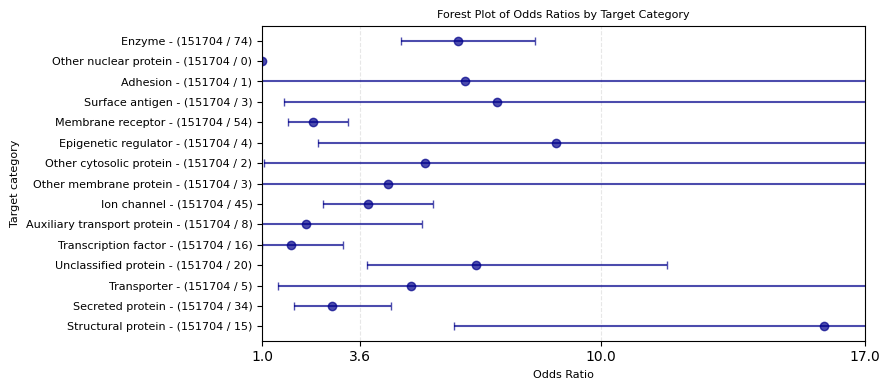

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasources and drugsources
# combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(9, 4))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Target category", fontsize=8)
plt.title("Forest Plot of Odds Ratios by Target Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(1, 17)
plt.xticks([1, 3.6, 10, 17])

# Adjust layout and show
plt.tight_layout()
plt.show()


In [66]:
import pandas as pd

all_enrich = []

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)


for tid in l1_classes:
    print(tid)

    target_to_use = (
        target.filter(f.array_contains(f.col("targetClass.label"), tid))
        .select("id")
        .withColumnRenamed("id", "targetId")
    )
    chembl_evidence_filtered = chembl_evidence.join(
        target_to_use,
        on="targetId",
        how="left_anti",
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence_filtered,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = tid
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


Enzyme


26/01/26 15:21:16 WARN CacheManager: Asked to cache already cached data.


Other nuclear protein


26/01/26 15:21:49 WARN CacheManager: Asked to cache already cached data.


Adhesion


26/01/26 15:22:10 WARN CacheManager: Asked to cache already cached data.


Surface antigen


26/01/26 15:22:30 WARN CacheManager: Asked to cache already cached data.


Membrane receptor


26/01/26 15:22:50 WARN CacheManager: Asked to cache already cached data.


Epigenetic regulator


26/01/26 15:23:07 WARN CacheManager: Asked to cache already cached data.


Other cytosolic protein


26/01/26 15:23:25 WARN CacheManager: Asked to cache already cached data.


Other membrane protein


26/01/26 15:23:41 WARN CacheManager: Asked to cache already cached data.


Ion channel


26/01/26 15:23:56 WARN CacheManager: Asked to cache already cached data.


Auxiliary transport protein


26/01/26 15:24:13 WARN CacheManager: Asked to cache already cached data.


Transcription factor


26/01/26 15:24:27 WARN CacheManager: Asked to cache already cached data.


Unclassified protein


26/01/26 15:24:45 WARN CacheManager: Asked to cache already cached data.


Transporter


26/01/26 15:25:18 WARN CacheManager: Asked to cache already cached data.


Secreted protein


26/01/26 15:25:50 WARN CacheManager: Asked to cache already cached data.


Structural protein


26/01/26 15:26:22 WARN CacheManager: Asked to cache already cached data.


In [69]:
df_concat = pd.concat(all_enrich, ignore_index=True)

combined_enrich_4 = df_concat[df_concat["clinicalPhase"] == "4+"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "Pharmaprojects"]
combined_enrich_4 = combined_enrich_4[combined_enrich_4["drugsource"] != "no_train_chembl"]
combined_enrich_4 = combined_enrich_4.iloc[::-1]

combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
44,4+,3.458694,6.838065e-44,2.945902,4.060749,2.684598,2.401530,3.001030,1.368017e-67,31116,4134,494,227,151704,Structural protein,full_chembl
41,4+,3.715174,5.469424e-44,3.136610,4.400457,2.815880,2.510665,3.158201,5.319017e-70,31380,4183,420,208,151704,Secreted protein,full_chembl
38,4+,3.625338,2.164094e-48,3.095002,4.246548,2.775331,2.489926,3.093450,6.653779e-76,31537,4165,495,237,151704,Transporter,full_chembl
35,4+,3.473245,6.121354e-43,2.950165,4.089069,2.672865,2.389883,2.989354,1.895195e-66,29945,4125,464,222,151704,Unclassified protein,full_chembl
32,4+,3.817042,4.502532e-49,3.242440,4.493470,2.873854,2.574062,3.208563,1.080712e-78,31001,4088,449,226,151704,Transcription factor,full_chembl
29,4+,3.670239,1.467880e-48,3.129855,4.303923,2.802412,2.512806,3.125395,1.531045e-76,31688,4157,486,234,151704,Auxiliary transport protein,full_chembl
26,4+,3.710209,7.362886e-42,3.120479,4.411392,2.853209,2.529754,3.218020,2.136453e-65,23973,2988,426,197,151704,Ion channel,full_chembl
23,4+,3.597392,2.814577e-48,3.073110,4.211119,2.753945,2.472301,3.067674,1.214013e-75,32287,4316,497,239,151704,Other membrane protein,full_chembl
20,4+,3.600347,2.077055e-48,3.075604,4.214617,2.748937,2.468777,3.060890,6.448165e-76,31735,4291,493,240,151704,Other cytosolic protein,full_chembl
17,4+,3.627378,1.723131e-48,3.096485,4.249292,2.764873,2.482244,3.079683,2.710142e-76,31998,4311,487,238,151704,Epigenetic regulator,full_chembl


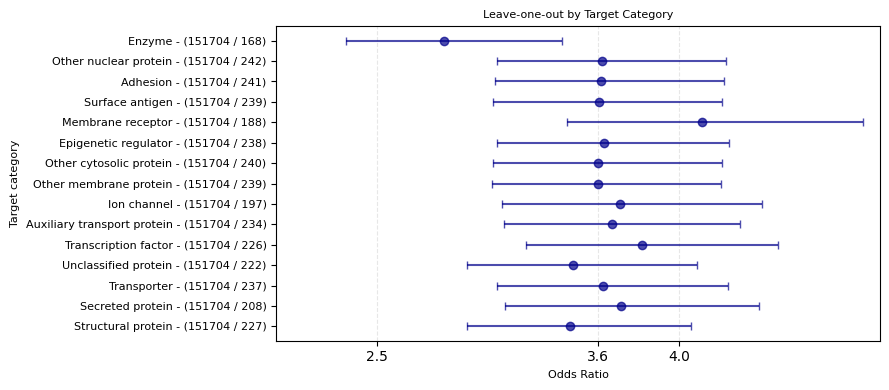

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasources and drugsources
# combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)
unique_datasources = combined_enrich_4["datasource"].unique()
unique_drugsources = combined_enrich_4["drugsource"].unique()
colors = ["darkblue", "green"]  # Two different colors for the two drugsources

# Create the plot
plt.figure(figsize=(9, 4))

# Create y-positions for each datasource group
y_positions = []
y_labels = []
y_pos = 0

for datasource in unique_datasources:
    datasource_data = combined_enrich_4[combined_enrich_4["datasource"] == datasource]

    for i, drugsource in enumerate(unique_drugsources):
        drugsource_data = datasource_data[datasource_data["drugsource"] == drugsource]

        if not drugsource_data.empty:
            for _, row in drugsource_data.iterrows():
                odds_ratio = row["odds_ratio"]
                ci_low = row["ci_low"]
                ci_high = row["ci_high"]

                # Plot the point with error bars
                plt.errorbar(
                    odds_ratio,
                    y_pos,
                    xerr=[[odds_ratio - ci_low], [ci_high - odds_ratio]],
                    fmt="o",
                    color=colors[i],
                    ecolor=colors[i],
                    capsize=3,
                    alpha=0.7,
                    label=drugsource if datasource == unique_datasources[0] else "",
                )

                # Create label
                label = f"{datasource} - ({row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']})"
                y_labels.append(label)
                y_positions.append(y_pos)
                y_pos += 1

    # Add some spacing between datasource groups
    y_pos += 0.5

# Customize the plot
# plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio", fontsize=8)
plt.ylabel("Target category", fontsize=8)
plt.title("Leave-one-out by Target Category", fontsize=8)

# Set y-tick labels
plt.yticks(y_positions, y_labels, fontsize=8)
# plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.xlim(2, 5)
plt.xticks([2.5, 3.6, 4])

# Adjust layout and show
plt.tight_layout()
plt.show()
